# Lecture 10 (file family L09) · Non-Maximum Suppression, one decision at a time

**One idea:** dense detectors produce several boxes for one object. NMS greedily lets the highest-scoring box claim its high-IoU neighbourhood **within one image and class**.

You will audit two real Oxford-IIIT Pet images and official head ROIs, predict a constructed A–E ledger, print the complete grouped trace, visualize each iteration over real pixels, test class-aware NMS, and find a threshold failure case. **No detector was run.**

**Clock map:** `TRAIN` produces head outputs; `INFER` decodes boxes, forms class scores, filters, and runs NMS; `EVAL` then matches the frozen ranked detections to ground truth. This notebook stays on the `INFER` clock; the companion notebook owns matching and AP.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

TEAL, ORANGE, GREEN, RED, BLUE, SLATE = '#2A7F7F', '#F57C00', '#20A84A', '#E34850', '#2D6FBB', '#59636E'

## 0 · Load the real two-image mini-batch

`I1=Abyssinian_1` and `I2=Bengal_10` are OBSERVED Oxford-IIIT Pet photographs; their XML tight-head ROIs are GT. A/B/E belong to I1, C/D belong to I2, and all five boxes/scores are CONSTRUCTED teaching records. IoU, grouped NMS, overlays, and the later matching/AP are COMPUTED. MODEL OUTPUT is empty.

The loader is local-first and uses SHA-pinned raw GitHub fallback in Colab.

I1: Abyssinian_1  GT=[332, 71, 425, 158]  pixels=[600, 400]
I2: Bengal_10  GT=[314, 59, 446, 219]  pixels=[500, 375]
OBSERVED/GT verified; CONSTRUCTED A–E; COMPUTED NMS; MODEL OUTPUT none


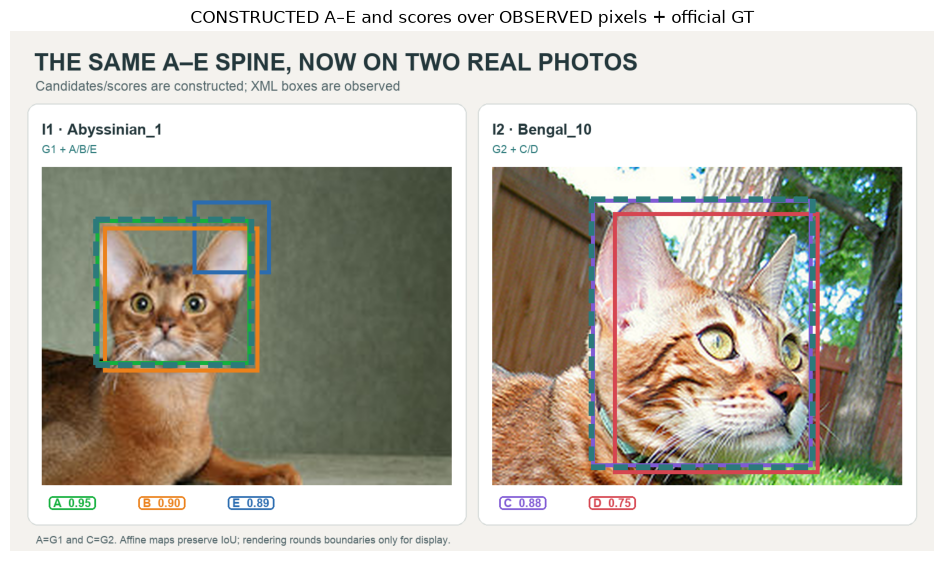

In [2]:
from pathlib import Path
from urllib.request import urlretrieve
import csv, hashlib, json, tempfile
import xml.etree.ElementTree as ET

RAW_ROOT = 'https://raw.githubusercontent.com/nipunbatra/dl-teaching/master/'
ASSET_SPECS = {
    'manifest': ('shared/vision-evidence/oxford-iiit-pet/l9/evidence.json', 'b539bc41f383d52f95ed2abeeaf764ccf325a1a03b000be7d377b075cac2836a'),
    'candidates': ('shared/vision-evidence/oxford-iiit-pet/l9/candidates.csv', '3a270c23854ed92d0870c796df7db2b1b33a73a69a1c39dee47be9bbd5d1d4fa'),
    'nms_trace': ('shared/vision-evidence/oxford-iiit-pet/l9/nms-trace.csv', 'bc802ddfca8edfecf979c31088a60c8858ad02c1a2493968d90d777cba49a494'),
    'candidates_plate': ('shared/vision-evidence/oxford-iiit-pet/l9/real-candidates.png', '1ca4372b8c062c4e4cb183c060669bdf3ea99c7884f0ae13f822f65f4570cdb6'),
    'nms_plate': ('shared/vision-evidence/oxford-iiit-pet/l9/real-nms-trace.png', '7b53928e5d66469319adc69382d2fe1e17a08c95cd669b368c17180eb1b8c177'),
    'i1_image': ('shared/vision-evidence/oxford-iiit-pet/Abyssinian_1.jpg', '2533197401eebe9410ea4d063f86c43fbd2666f3e8165a38aca155c0d09c21be'),
    'i1_xml': ('shared/vision-evidence/oxford-iiit-pet/Abyssinian_1.xml', 'bea13ddcf1dc171e39da5ce2c134b1dc8c247a9f1bb21cc2056f37f7a423a51f'),
    'i2_image': ('shared/vision-evidence/oxford-iiit-pet/l9/Bengal_10.jpg', '4cc958fc6bb47738488fdc83a3053f01ce2937c9fbcaf5db2e649a1d612f8725'),
    'i2_xml': ('shared/vision-evidence/oxford-iiit-pet/l9/Bengal_10.xml', '9a6e7d513d999b23cde839a6efce908e2e1472d14d69f13d671e9db9cdb09ae6'),
}

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def local_first(key):
    rel, expected = ASSET_SPECS[key]
    for root in (Path.cwd(), *Path.cwd().parents):
        candidate = root / rel
        if candidate.is_file() and sha256(candidate) == expected:
            return candidate
    cache = Path(tempfile.gettempdir()) / 'dl-teaching-l09-evidence'
    cache.mkdir(parents=True, exist_ok=True)
    target = cache / Path(rel).name
    if not target.is_file() or sha256(target) != expected:
        urlretrieve(RAW_ROOT + rel, target)
    actual = sha256(target)
    assert actual == expected, f'{key}: SHA mismatch {actual}'
    return target

manifest = json.loads(local_first('manifest').read_text())
assert manifest['schema_version'] == 2
assert manifest['build']['builder_sha256'] == '1e6d3312df89424974b1fab8ccdbc5e11963dd4b6d6c802d64d33b09380fb3e1'
assert manifest['evidence_taxonomy']['model_output'] == []

def voc_half_open(path):
    box = ET.parse(path).getroot().find('.//bndbox')
    xmin, ymin, xmax, ymax = [int(box.find(k).text) for k in ('xmin','ymin','xmax','ymax')]
    return [xmin - 1, ymin - 1, xmax, ymax]

for image_id, xml_key in [('I1','i1_xml'), ('I2','i2_xml')]:
    sample = manifest['source']['samples'][image_id]
    assert voc_half_open(local_first(xml_key)) == sample['gt_source_xyxy_half_open']
    image = plt.imread(local_first(image_id.lower() + '_image'))
    assert [image.shape[1], image.shape[0]] == sample['image_size']
    print(f"{image_id}: {sample['stem']}  GT={sample['gt_source_xyxy_half_open']}  pixels={sample['image_size']}")
print('OBSERVED/GT verified; CONSTRUCTED A–E; COMPUTED NMS; MODEL OUTPUT none')

fig, ax = plt.subplots(figsize=(12, 6.75))
ax.imshow(plt.imread(local_first('candidates_plate')))
ax.axis('off'); ax.set_title('CONSTRUCTED A–E and scores over OBSERVED pixels + official GT')
plt.show()

## 1 · `INFER` — five constructed candidates in a two-image mini-batch

A, B, and E are `head` candidates for I1; C and D are `head` candidates for I2. Scores are A $.95$, B $.90$, E $.89$, C $.88$, D $.75$. These are pedagogical constructions, not head outputs. Boxes use continuous/half-open corners, so area has no inclusive-pixel `+1`.

**Predict before running:** with $\tau=0.5$ and NMS grouped by `(image_id, class)`, which three boxes should survive?

In [3]:
names = np.array(['A','B','E','C','D'])
image_ids = np.array(['I1','I1','I1','I2','I2'])
boxes = np.array([
    [10,10,50,50],   # A, exact G1 in I1
    [12,12,52,52],   # B, duplicate candidate in I1
    [35, 5,55,25],   # E, isolated candidate in I1
    [60,15,90,55],   # C, exact G2 in I2
    [63,17,91,56],   # D, duplicate candidate in I2
], float)
scores = np.array([.95,.90,.89,.88,.75])
classes = np.array(['head','head','head','head','head'])
with local_first('candidates').open(newline='') as handle:
    evidence_rows = list(csv.DictReader(handle))
assert [(row['id'], row['image'], row['class']) for row in evidence_rows] == [
    (name, image_id, 'head') for name, image_id in zip(names, image_ids)
]

In [4]:
def area(b):
    return max(0., b[2]-b[0]) * max(0., b[3]-b[1])

def iou(a,b):
    left, top = max(a[0],b[0]), max(a[1],b[1])
    right, bottom = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0.,right-left) * max(0.,bottom-top)
    union = area(a)+area(b)-inter
    return inter/union if union else 0.

pairwise = np.array([
    [iou(a,b) if image_ids[i] == image_ids[j] else np.nan for j,b in enumerate(boxes)]
    for i,a in enumerate(boxes)
])
print('pairwise IoU, rows/columns A B E C D; nan = forbidden cross-image comparison')
print(np.round(pairwise,3))
print(f'IoU(A,B)={pairwise[0,1]:.3f}; IoU(C,D)={pairwise[3,4]:.3f}; IoU(A,E)={pairwise[0,2]:.3f}')
assert np.isclose(pairwise[0,1], 361/439)
assert np.isclose(pairwise[3,4], 171/211)
assert np.isclose(pairwise[0,2], 9/71)

pairwise IoU, rows/columns A B E C D; nan = forbidden cross-image comparison
[[1.    0.822 0.127   nan   nan]
 [0.822 1.    0.124   nan   nan]
 [0.127 0.124 1.      nan   nan]
 [  nan   nan   nan 1.    0.81 ]
 [  nan   nan   nan 0.81  1.   ]]
IoU(A,B)=0.822; IoU(C,D)=0.810; IoU(A,E)=0.127


## 2 · `INFER` — implement the greedy loop

The local kernel below is agnostic to metadata: 1. sort by score; 2. keep the highest remaining box; 3. suppress neighbours with IoU $>\tau$; 4. repeat. The wrapper must partition records by **both image identity and class** before invoking that kernel.

The sort is stable, so equal scores preserve input order; other implementations may choose a different tied box. Inspect the trace, not only the final list.

In [5]:
def nms(boxes, scores, threshold=.5):
    order = list(np.argsort(-scores, kind='stable'))
    keep, trace = [], []
    while order:
        i = order.pop(0)
        keep.append(i)
        removed, survivors = [], []
        for j in order:
            overlap = iou(boxes[i], boxes[j])
            if overlap > threshold:
                removed.append((j, overlap))
            else:
                survivors.append(j)
        trace.append({'kept': i, 'removed': removed, 'remaining': survivors.copy()})
        order = survivors
    return keep, trace

def grouped_nms(boxes, scores, image_ids, classes, threshold=.5):
    keep, trace = [], []
    groups = list(dict.fromkeys(zip(image_ids.tolist(), classes.tolist())))
    for image_id, cls in groups:
        idx = np.flatnonzero((image_ids == image_id) & (classes == cls))
        local_keep, local_trace = nms(boxes[idx], scores[idx], threshold)
        keep.extend(idx[local_keep])
        for event in local_trace:
            trace.append({
                'image': image_id, 'class': cls,
                'kept': int(idx[event['kept']]),
                'removed': [(int(idx[j]), overlap) for j, overlap in event['removed']],
                'remaining': [int(idx[j]) for j in event['remaining']],
            })
    keep = sorted(keep, key=lambda i: -scores[i])
    trace = sorted(trace, key=lambda event: -scores[event['kept']])
    return keep, trace

keep, trace = grouped_nms(boxes, scores, image_ids, classes, threshold=.5)
for step, event in enumerate(trace,1):
    k = event['kept']
    removed = ', '.join(f'{names[j]} (IoU {ov:.3f})' for j,ov in event['removed']) or 'none'
    remaining = ', '.join(names[event['remaining']]) or 'none'
    print(f"step {step}: {event['image']}/{event['class']} keep {names[k]} ({scores[k]:.2f}); suppress {removed}; remaining {remaining}")
print('globally score-sorted survivors:', names[keep].tolist())
assert names[keep].tolist() == ['A','E','C']
with local_first('nms_trace').open(newline='') as handle:
    recorded_trace = list(csv.DictReader(handle))
assert [(row['image'], row['action'], row['candidate']) for row in recorded_trace] == [
    ('I1','keep','A'), ('I1','suppress','B'), ('I1','keep','E'),
    ('I2','keep','C'), ('I2','suppress','D'),
]

step 1: I1/head keep A (0.95); suppress B (IoU 0.822); remaining E
step 2: I1/head keep E (0.89); suppress none; remaining none
step 3: I2/head keep C (0.88); suppress D (IoU 0.810); remaining none
globally score-sorted survivors: ['A', 'E', 'C']


## 3 · `INFER` — see the greedy state change

The plate below shows the exact grouped trace on the two real photographs. Ground truth is deliberately hidden on the `INFER` clock. Explain why B is compared only with I1/head candidates, D only with I2/head candidates, and isolated E survives.

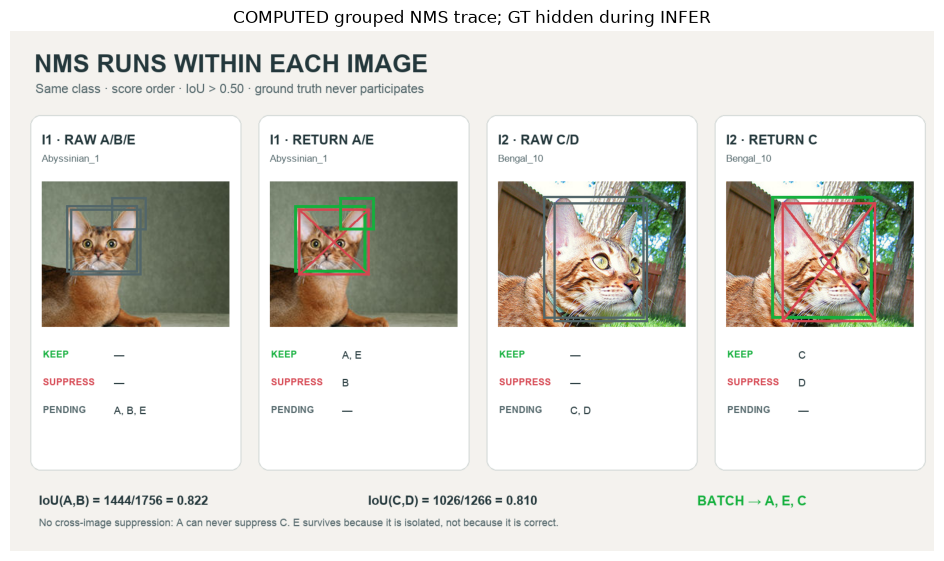

In [6]:
fig, ax = plt.subplots(figsize=(12, 6.75))
ax.imshow(plt.imread(local_first('nms_plate')))
ax.axis('off'); ax.set_title('COMPUTED grouped NMS trace; GT hidden during INFER')
plt.show()

## 4 · `INFER` — sweep the IoU threshold

**Predict:** in this fixed two-image mini-batch of two duplicate pairs plus isolated E, does a larger threshold suppress more boxes or fewer boxes? Greedy NMS survivor counts are **not** guaranteed to be monotone for every possible overlap graph.

In [7]:
for threshold in [.3,.5,.8,.9]:
    kept,_ = grouped_nms(boxes,scores,image_ids,classes,threshold)
    print(f'tau={threshold:.1f}: keep {names[kept].tolist()}')

# This assertion is specific to this disjoint-pair scene, not a theorem about greedy NMS.
counts = [len(grouped_nms(boxes,scores,image_ids,classes,t)[0]) for t in np.linspace(0,1,51)]
assert np.all(np.diff(counts) >= 0)

tau=0.3: keep ['A', 'E', 'C']
tau=0.5: keep ['A', 'E', 'C']
tau=0.8: keep ['A', 'E', 'C']
tau=0.9: keep ['A', 'B', 'E', 'C', 'D']


## 5 · `INFER` — why NMS is usually class-aware

Add a **hand** box H to I1 so that it overlaps head box A. Image-aware but class-agnostic NMS may remove H; grouping by `(image_id, class)` must preserve it.

**Predict:** which comparison must be forbidden to preserve H?

In [8]:
boxes6 = np.vstack([boxes, [9,9,49,49]])
scores6 = np.r_[scores,.87]
names6 = np.append(names,'H')
image_ids6 = np.append(image_ids,'I1')
classes6 = np.append(classes,'hand')

agnostic,_ = grouped_nms(boxes6,scores6,image_ids6,np.repeat('all',len(boxes6)),.5)
aware,_ = grouped_nms(boxes6,scores6,image_ids6,classes6,.5)
agnostic_labels=[(str(names6[i]),str(classes6[i])) for i in agnostic]
aware_labels=[(str(names6[i]),str(classes6[i])) for i in aware]
print('image-aware, class-agnostic:',agnostic_labels)
print('image + class aware         :',aware_labels)
assert 'H' not in names6[agnostic] and 'H' in names6[aware]

image-aware, class-agnostic: [('A', 'head'), ('E', 'head'), ('C', 'head')]
image + class aware         : [('A', 'head'), ('E', 'head'), ('C', 'head'), ('H', 'hand')]


## 6 · `INFER` — put scoring, thresholding and NMS together

A detector may form a class score as $s_{head}=o\,p(head\mid object)$. Treat A–E's constructed scores as already formed, append I1/head candidate F with $o=.20$ and $p(head\mid object)=.99$, remove scores below $0.30$, then run grouped NMS.

**Predict:** can a candidate with high class probability still be removed by the score threshold?

In [9]:
f_objectness, f_p_cup_given_object = .20, .99
f_score = f_objectness * f_p_cup_given_object
head_score = np.r_[scores, f_score]
pipeline_boxes = np.vstack([boxes, [20,45,35,60]])
pipeline_names = np.append(names,'F')
pipeline_images = np.append(image_ids,'I1')
pipeline_classes = np.append(classes,'head')
mask = head_score >= .30
kept_local,_ = grouped_nms(pipeline_boxes[mask],head_score[mask],pipeline_images[mask],pipeline_classes[mask],.5)
final_idx = np.flatnonzero(mask)[kept_local]
print('constructed class scores A–E:', scores.tolist())
print(f'F: {f_objectness:.2f} x {f_p_cup_given_object:.2f} = {f_score:.3f}')
print('after score threshold:',pipeline_names[mask].tolist())
print('after NMS            :',pipeline_names[final_idx].tolist())
assert pipeline_names[final_idx].tolist() == ['A','E','C']

constructed class scores A–E: [0.95, 0.9, 0.89, 0.88, 0.75]
F: 0.20 x 0.99 = 0.198
after score threshold: ['A', 'B', 'E', 'C', 'D']
after NMS            : ['A', 'E', 'C']


## 7 · `INFER` boundary — try to break NMS

Create two **distinct same-class objects** whose correct boxes overlap. Give the slightly higher-scoring one priority. Find a threshold that wrongly suppresses the other.

Then explain one possible remedy: raise $\tau$, use Soft-NMS to decay rather than delete, or use a learned/set-based alternative. There is no universally safe threshold.

In [10]:
nearby = np.array([[10,10,40,50],[24,10,54,50]],float)
nearby_scores = np.array([.92,.90])
overlap = iou(nearby[0],nearby[1])
print(f'IoU between two distinct-object boxes = {overlap:.3f}')
for threshold in [.25,.35,.50,.70]:
    k,_=nms(nearby,nearby_scores,threshold)
    print(f'tau={threshold:.2f}: keep {len(k)} object(s)')

IoU between two distinct-object boxes = 0.364
tau=0.25: keep 1 object(s)
tau=0.35: keep 1 object(s)
tau=0.50: keep 2 object(s)
tau=0.70: keep 2 object(s)


## Explain the trace

1. Why must boxes be grouped by image identity before any IoU suppression?
2. Why does increasing $\tau$ keep more boxes in this mini-batch, yet not guarantee a globally monotone survivor count for every greedy overlap graph?
3. Why does A suppress B only in I1 while C suppresses D only in I2?
4. Why is class-aware NMS appropriate for an overlapping head and hand?
5. What information does standard NMS ignore that a learned post-processor might use?

## Takeaway

- The photos and XML ROIs are observed/GT; A–E and their scores are constructed; NMS and overlays are computed; there is no model output.
- NMS is an `INFER`-clock greedy algorithm on **decoded boxes + scores**, not a learned layer.
- Its order matters: the current maximum claims a neighbourhood before the next survivor is considered.
- Group by `(image_id, class)`: cross-image suppression is always invalid, while class-aware NMS prevents cross-class suppression.
- In the two-image mini-batch NMS keeps A, E, C; on the `EVAL` clock, image-aware one-to-one matching later marks A and C TP and isolated E FP.